In [2]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260513_derived_membership.csv"
alpha = 0.05
min_significant_age_groups = 4
categorical_numeric_max_unique = 10

age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

binary_replace_map = {
    True: 1,
    False: 0,
    "true": 1,
    "false": 0,
    "y": 1,
    "n": 0,
    "yes": 1,
    "no": 0,
}

# CSV 로드
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 차이 검정
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )

    return pvalue

# 이진형 정규화
def normalize_binary_series(series):
    temp = series.dropna().copy()

    if len(temp) == 0:
        return pd.Series(dtype="int64")

    if pd.api.types.is_object_dtype(temp) or pd.api.types.is_string_dtype(temp):
        temp = temp.astype(str).str.strip().str.lower()

    temp = temp.replace(binary_replace_map)
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]

    return temp.astype(int)

# 이진형 판별
def is_binary_feature(series):
    temp = series.dropna().copy()

    if len(temp) == 0:
        return False

    if pd.api.types.is_object_dtype(temp) or pd.api.types.is_string_dtype(temp):
        temp = temp.astype(str).str.strip().str.lower()

    temp = temp.replace(binary_replace_map)
    temp = pd.to_numeric(temp, errors="coerce")

    if temp.isna().any():
        return False

    return set(temp.unique()).issubset({0, 1})

# 피처 타입 추론
def infer_feature_type(series):
    non_null = series.dropna()

    if len(non_null) == 0:
        return "skip"

    if is_binary_feature(non_null):
        return "binary"

    numeric = pd.to_numeric(non_null, errors="coerce")

    if numeric.notna().all():
        unique_count = numeric.nunique()
        integer_like_flag = np.all(np.isclose(numeric % 1, 0))

        if unique_count <= categorical_numeric_max_unique and integer_like_flag:
            return "categorical"

        return "numeric"

    return "categorical"

# 이진형 검정
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    return run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )

# 범주형 검정
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(contingency.values, alternative="two-sided")
            return fisher_pvalue

        return chi2_pvalue

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue

# 수치형 검정
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue

# 피처별 p-value 계산
def get_feature_pvalue(df0_age, df1_age, feature_name, feature_type_map):
    feature_type = feature_type_map[feature_name]

    if feature_type == "binary":
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_type == "categorical":
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_type == "numeric":
        return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

    return np.nan

# 데이터 준비
df = read_membership_csv(file_path)
df = preprocess(df)

df0 = df[df["is_promotion"] == 0].copy()
df1 = df[df["is_promotion"] == 1].copy()

# age_group별 이탈률 집계
g0 = (
    df0.groupby("age_group", observed=True)["churn"]
    .agg(churn_0="sum", total_0="count")
    .reset_index()
)

g1 = (
    df1.groupby("age_group", observed=True)["churn"]
    .agg(churn_1="sum", total_1="count")
    .reset_index()
)

merged = pd.merge(g0, g1, on="age_group", how="inner")

merged["age_group"] = pd.Categorical(
    merged["age_group"],
    categories=age_labels,
    ordered=True
)
merged = merged.sort_values("age_group").reset_index(drop=True)

# 유의한 age_group 추출
significant_age_groups = []

for _, row in merged.iterrows():
    churn_0 = int(row["churn_0"])
    total_0 = int(row["total_0"])
    churn_1 = int(row["churn_1"])
    total_1 = int(row["total_1"])

    if total_0 == 0 or total_1 == 0:
        continue

    pvalue = run_test(churn_0, total_0, churn_1, total_1)

    if pd.notna(pvalue) and pvalue < alpha:
        significant_age_groups.append(str(row["age_group"]))

# 후보 피처 선정
candidate_features = [
    col for col in df.columns
    if col not in exclude_features
]

feature_type_map = {
    feature_name: infer_feature_type(df[feature_name])
    for feature_name in candidate_features
}

# age_group별 피처 차이 검정
significant_age_groups_by_feature = defaultdict(list)

for age_group in significant_age_groups:
    df0_age = df0[df0["age_group"].astype(str) == age_group].copy()
    df1_age = df1[df1["age_group"].astype(str) == age_group].copy()

    if len(df0_age) == 0 or len(df1_age) == 0:
        continue

    for feature_name in candidate_features:
        pvalue = get_feature_pvalue(df0_age, df1_age, feature_name, feature_type_map)

        if pd.notna(pvalue) and pvalue < alpha:
            significant_age_groups_by_feature[feature_name].append(age_group)

# 결과 정리
feature_summary = []

for feature_name in candidate_features:
    matched_age_groups = [
        age_group for age_group in age_labels
        if age_group in significant_age_groups_by_feature[feature_name]
    ]

    if len(matched_age_groups) >= min_significant_age_groups:
        feature_summary.append(
            (feature_name, len(matched_age_groups), matched_age_groups)
        )

feature_summary.sort(key=lambda x: (-x[1], x[0]))

# 결과 출력
if not feature_summary:
    print("없음")
else:
    grouped_result = defaultdict(list)

    for feature_name, matched_count, matched_age_groups in feature_summary:
        grouped_result[matched_count].append((feature_name, matched_age_groups))

    for matched_count in sorted(grouped_result.keys(), reverse=True):
        print(f"[{matched_count}개 age_group 유의]")
        for feature_name, matched_age_groups in grouped_result[matched_count]:
            print(f"{feature_name} : {', '.join(matched_age_groups)}")


[5개 age_group 유의]
is_churn_prevented : 10대, 20대, 30대, 40대, 60대
is_premium : 10대, 20대, 30대, 40대, 60대
is_user_verified : 10대, 20대, 30대, 40대, 60대
max_screen : 10대, 20대, 30대, 40대, 60대
payment_device : 10대, 20대, 30대, 40대, 60대
payment_is_ios : 10대, 20대, 30대, 40대, 60대
payment_is_mobile : 10대, 20대, 30대, 40대, 60대
payment_is_pc : 10대, 20대, 30대, 40대, 60대
product_code : 10대, 20대, 30대, 40대, 60대
reg_hour_morning : 10대, 20대, 30대, 40대, 60대
[4개 age_group 유의]
gender : 20대, 30대, 40대, 60대
is_male : 20대, 30대, 40대, 60대
is_standard : 20대, 30대, 40대, 60대
price : 10대, 20대, 30대, 60대
reg_hour_evening : 10대, 20대, 30대, 40대


In [5]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260513_derived_membership.csv"
alpha = 0.05
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

df0 = membership[membership["is_promotion"] == 0].copy()
df1 = membership[membership["is_promotion"] == 1].copy()

g0 = (
    df0.groupby("age_group", observed=True)["churn"]
    .agg(churn_0="sum", total_0="count")
    .reset_index()
)

g1 = (
    df1.groupby("age_group", observed=True)["churn"]
    .agg(churn_1="sum", total_1="count")
    .reset_index()
)

merged = pd.merge(g0, g1, on="age_group", how="inner")

merged["age_group"] = pd.Categorical(
    merged["age_group"],
    categories=age_labels,
    ordered=True
)
merged = merged.sort_values("age_group").reset_index(drop=True)

significant_age_groups = []

for _, row in merged.iterrows():
    churn_0 = int(row["churn_0"])
    total_0 = int(row["total_0"])
    churn_1 = int(row["churn_1"])
    total_1 = int(row["total_1"])

    if total_0 == 0 or total_1 == 0:
        continue

    pvalue, _ = run_test(churn_0, total_0, churn_1, total_1)

    if pvalue < alpha:
        significant_age_groups.append(str(row["age_group"]))

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0.columns
    if col in df1.columns and col not in exclude_features
]

# 이진형 정규화 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    pvalue, _ = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue

# 범주형 검정 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    combined = pd.concat([s0, s1], ignore_index=True)
    if combined.nunique() <= 1:
        return 1.0

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)
        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(contingency.values, alternative="two-sided")
            return fisher_pvalue
        return chi2_pvalue

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue

# 수치형 검정 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue

# 피처별 p-value 계산 정의
def get_feature_pvalue(df0_age, df1_age, feature_name):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

significant_age_groups_by_feature = defaultdict(list)

for age_group in significant_age_groups:
    df0_age = df0[df0["age_group"].astype(str) == age_group].copy()
    df1_age = df1[df1["age_group"].astype(str) == age_group].copy()

    if len(df0_age) == 0 or len(df1_age) == 0:
        continue

    for feature_name in candidate_features:
        pvalue = get_feature_pvalue(df0_age, df1_age, feature_name)

        if pd.notna(pvalue) and pvalue < alpha:
            significant_age_groups_by_feature[feature_name].append(age_group)

grouped_results = defaultdict(list)

for feature_name in candidate_features:
    matched_age_groups = [
        age_group for age_group in age_labels
        if age_group in significant_age_groups_by_feature[feature_name]
    ]

    if len(matched_age_groups) >= 3:
        grouped_results[len(matched_age_groups)].append(
            (feature_name, matched_age_groups)
        )

if not grouped_results:
    print("없음")
else:
    sorted_group_counts = sorted(grouped_results.keys(), reverse=True)

    for idx, group_count in enumerate(sorted_group_counts):
        if idx > 0:
            print()

        print(f"[{group_count}개 age_group 유의]")

        for feature_name, matched_age_groups in sorted(grouped_results[group_count]):
            print(f"{feature_name} : {', '.join(matched_age_groups)}")


[5개 age_group 유의]
is_churn_prevented : 10대, 20대, 30대, 40대, 60대
is_premium : 10대, 20대, 30대, 40대, 60대
is_user_verified : 10대, 20대, 30대, 40대, 60대
max_screen : 10대, 20대, 30대, 40대, 60대
payment_device : 10대, 20대, 30대, 40대, 60대
payment_is_ios : 10대, 20대, 30대, 40대, 60대
payment_is_mobile : 10대, 20대, 30대, 40대, 60대
payment_is_pc : 10대, 20대, 30대, 40대, 60대
product_code : 10대, 20대, 30대, 40대, 60대
reg_hour_morning : 10대, 20대, 30대, 40대, 60대

[4개 age_group 유의]
gender : 20대, 30대, 40대, 60대
is_male : 20대, 30대, 40대, 60대
is_standard : 20대, 30대, 40대, 60대
price : 10대, 20대, 30대, 60대
reg_hour_evening : 10대, 20대, 30대, 40대

[3개 age_group 유의]
is_female : 20대, 40대, 60대
payment_is_android : 20대, 40대, 60대
reg_is_weekend : 10대, 20대, 30대


In [6]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260513_derived_membership.csv"
alpha = 0.05
min_age_group_count = 2
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 프로모션 그룹 분리
df0 = membership[membership["is_promotion"] == 0].copy()
df1 = membership[membership["is_promotion"] == 1].copy()

# age_group별 이탈자 수 집계
g0 = (
    df0.groupby("age_group", observed=True)["churn"]
    .agg(churn_0="sum", total_0="count")
    .reset_index()
)

g1 = (
    df1.groupby("age_group", observed=True)["churn"]
    .agg(churn_1="sum", total_1="count")
    .reset_index()
)

merged = pd.merge(g0, g1, on="age_group", how="inner")

merged["age_group"] = pd.Categorical(
    merged["age_group"],
    categories=age_labels,
    ordered=True
)
merged = merged.sort_values("age_group").reset_index(drop=True)

# 이탈률 차이 유의 age_group 추출
significant_age_groups = []

for _, row in merged.iterrows():
    churn_0 = int(row["churn_0"])
    total_0 = int(row["total_0"])
    churn_1 = int(row["churn_1"])
    total_1 = int(row["total_1"])

    if total_0 == 0 or total_1 == 0:
        continue

    pvalue, _ = run_test(churn_0, total_0, churn_1, total_1)

    if pvalue < alpha:
        significant_age_groups.append(str(row["age_group"]))

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0.columns
    if col in df1.columns and col not in exclude_features
]

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    pvalue, _ = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue

        return chi2_pvalue

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue

# 피처별 p-value 계산 함수 정의
def get_feature_pvalue(df0_age, df1_age, feature_name):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# age_group별 유의 결과 저장
significant_age_groups_by_feature = defaultdict(list)

for age_group in significant_age_groups:
    df0_age = df0[df0["age_group"].astype(str) == age_group].copy()
    df1_age = df1[df1["age_group"].astype(str) == age_group].copy()

    if len(df0_age) == 0 or len(df1_age) == 0:
        continue

    for feature_name in candidate_features:
        pvalue = get_feature_pvalue(df0_age, df1_age, feature_name)

        if pd.notna(pvalue) and pvalue < alpha:
            significant_age_groups_by_feature[feature_name].append(age_group)

# 출력용 결과 정리
grouped_results = defaultdict(list)

for feature_name in candidate_features:
    matched_age_groups = [
        age_group for age_group in age_labels
        if age_group in significant_age_groups_by_feature[feature_name]
    ]

    if len(matched_age_groups) >= min_age_group_count:
        grouped_results[len(matched_age_groups)].append(
            (feature_name, matched_age_groups)
        )

# 결과 출력
if not grouped_results:
    print("없음")
else:
    sorted_group_counts = sorted(grouped_results.keys(), reverse=True)

    for idx, group_count in enumerate(sorted_group_counts):
        if idx > 0:
            print()

        print(f"[{group_count}개 age_group 유의]")

        for feature_name, matched_age_groups in sorted(grouped_results[group_count]):
            print(f"{feature_name} : {', '.join(matched_age_groups)}")


[5개 age_group 유의]
is_churn_prevented : 10대, 20대, 30대, 40대, 60대
is_premium : 10대, 20대, 30대, 40대, 60대
is_user_verified : 10대, 20대, 30대, 40대, 60대
max_screen : 10대, 20대, 30대, 40대, 60대
payment_device : 10대, 20대, 30대, 40대, 60대
payment_is_ios : 10대, 20대, 30대, 40대, 60대
payment_is_mobile : 10대, 20대, 30대, 40대, 60대
payment_is_pc : 10대, 20대, 30대, 40대, 60대
product_code : 10대, 20대, 30대, 40대, 60대
reg_hour_morning : 10대, 20대, 30대, 40대, 60대

[4개 age_group 유의]
gender : 20대, 30대, 40대, 60대
is_male : 20대, 30대, 40대, 60대
is_standard : 20대, 30대, 40대, 60대
price : 10대, 20대, 30대, 60대
reg_hour_evening : 10대, 20대, 30대, 40대

[3개 age_group 유의]
is_female : 20대, 40대, 60대
payment_is_android : 20대, 40대, 60대
reg_is_weekend : 10대, 20대, 30대

[2개 age_group 유의]
age : 20대, 40대
reg_hour_night : 10대, 40대
watch_ratio_under_1m : 20대, 60대
watch_ratio_under_5m : 20대, 60대


## 10대

In [7]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260513_derived_membership.csv"
alpha = 0.05
target_age_group = "10대"
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Binary test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    pvalue, test_name = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue, test_name

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Categorical test skipped"

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0, "No variation"

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0, "No variation"

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue, "Fisher exact test"

        return chi2_pvalue, "Chi-square test"

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue, "Chi-square test"

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Numeric test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue, "Mann-Whitney U test"

# 피처별 검정 함수 정의
def get_feature_test_result(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 대상 나이대 필터링
target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

# 프로모션 그룹 분리
df0_age = target_df[target_df["is_promotion"] == 0].copy()
df1_age = target_df[target_df["is_promotion"] == 1].copy()

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0_age.columns
    if col in df1_age.columns and col not in exclude_features
]

# 유의 컬럼 추출
significant_results = []

for feature_name in candidate_features:
    pvalue, test_name = get_feature_test_result(
        df0_age,
        df1_age,
        feature_name,
        binary_features,
        categorical_features
    )

    if pd.notna(pvalue) and pvalue < alpha:
        significant_results.append(
            {
                "feature_name": feature_name,
                "pvalue": pvalue,
                "test_name": test_name,
            }
        )

# 결과 출력
if len(df0_age) == 0 or len(df1_age) == 0:
    print("없음")
elif not significant_results:
    print("없음")
else:
    result_df = pd.DataFrame(significant_results)
    result_df = result_df.sort_values(
        by=["pvalue", "feature_name"],
        ascending=[True, True]
    ).reset_index(drop=True)

    print(f"[{target_age_group} 유의 컬럼]")
    print(f"총 {len(result_df)}개")

    for _, row in result_df.iterrows():
        print(
            f"{row['feature_name']} | "
            f"p-value={row['pvalue']:.6g} | "
            f"검정법={row['test_name']}"
        )


[10대 유의 컬럼]
총 14개
price | p-value=2.90246e-48 | 검정법=Mann-Whitney U test
reg_hour_morning | p-value=1.38667e-15 | 검정법=Mann-Whitney U test
payment_device | p-value=4.34839e-13 | 검정법=Chi-square test
payment_is_ios | p-value=3.49356e-12 | 검정법=Mann-Whitney U test
product_code | p-value=4.002e-11 | 검정법=Chi-square test
is_churn_prevented | p-value=3.06145e-08 | 검정법=Two-proportion z-test
is_user_verified | p-value=1.48084e-07 | 검정법=Fisher exact test
is_premium | p-value=0.000236704 | 검정법=Mann-Whitney U test
reg_is_weekend | p-value=0.000398584 | 검정법=Mann-Whitney U test
reg_hour_evening | p-value=0.000752448 | 검정법=Mann-Whitney U test
max_screen | p-value=0.000767349 | 검정법=Chi-square test
payment_is_pc | p-value=0.00624722 | 검정법=Mann-Whitney U test
payment_is_mobile | p-value=0.00839822 | 검정법=Mann-Whitney U test
reg_hour_night | p-value=0.0319496 | 검정법=Mann-Whitney U test


## 20대

In [8]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260513_derived_membership.csv"
alpha = 0.05
target_age_group = "20대"
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Binary test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    pvalue, test_name = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue, test_name

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Categorical test skipped"

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0, "No variation"

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0, "No variation"

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue, "Fisher exact test"

        return chi2_pvalue, "Chi-square test"

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue, "Chi-square test"

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Numeric test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue, "Mann-Whitney U test"

# 피처별 검정 함수 정의
def get_feature_test_result(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 대상 나이대 필터링
target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

# 프로모션 그룹 분리
df0_age = target_df[target_df["is_promotion"] == 0].copy()
df1_age = target_df[target_df["is_promotion"] == 1].copy()

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0_age.columns
    if col in df1_age.columns and col not in exclude_features
]

# 유의 컬럼 추출
significant_results = []

for feature_name in candidate_features:
    pvalue, test_name = get_feature_test_result(
        df0_age,
        df1_age,
        feature_name,
        binary_features,
        categorical_features
    )

    if pd.notna(pvalue) and pvalue < alpha:
        significant_results.append(
            {
                "feature_name": feature_name,
                "pvalue": pvalue,
                "test_name": test_name,
            }
        )

# 결과 출력
if len(df0_age) == 0 or len(df1_age) == 0:
    print("없음")
elif not significant_results:
    print("없음")
else:
    result_df = pd.DataFrame(significant_results)
    result_df = result_df.sort_values(
        by=["pvalue", "feature_name"],
        ascending=[True, True]
    ).reset_index(drop=True)

    print(f"[{target_age_group} 유의 컬럼]")
    print(f"총 {len(result_df)}개")

    for _, row in result_df.iterrows():
        print(
            f"{row['feature_name']} | "
            f"p-value={row['pvalue']:.6g} | "
            f"검정법={row['test_name']}"
        )


[20대 유의 컬럼]
총 24개
payment_device | p-value=0 | 검정법=Chi-square test
price | p-value=0 | 검정법=Mann-Whitney U test
product_code | p-value=5.01904e-307 | 검정법=Chi-square test
payment_is_ios | p-value=1.66175e-266 | 검정법=Mann-Whitney U test
is_user_verified | p-value=1.77264e-115 | 검정법=Fisher exact test
max_screen | p-value=2.52297e-67 | 검정법=Chi-square test
payment_is_mobile | p-value=1.81589e-63 | 검정법=Mann-Whitney U test
is_premium | p-value=8.01992e-58 | 검정법=Mann-Whitney U test
reg_hour_morning | p-value=2.43847e-52 | 검정법=Mann-Whitney U test
is_churn_prevented | p-value=5.8934e-50 | 검정법=Two-proportion z-test
gender | p-value=1.18865e-34 | 검정법=Chi-square test
is_standard | p-value=2.97483e-27 | 검정법=Mann-Whitney U test
payment_is_pc | p-value=5.01746e-21 | 검정법=Mann-Whitney U test
reg_hour_evening | p-value=3.84683e-18 | 검정법=Mann-Whitney U test
age | p-value=5.25983e-10 | 검정법=Mann-Whitney U test
is_male | p-value=6.22014e-07 | 검정법=Mann-Whitney U test
reg_is_weekend | p-value=2.19344e-06 | 검정법=M

## 30대

In [9]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260513_derived_membership.csv"
alpha = 0.05
target_age_group = "30대"
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Binary test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    pvalue, test_name = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue, test_name

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Categorical test skipped"

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0, "No variation"

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0, "No variation"

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue, "Fisher exact test"

        return chi2_pvalue, "Chi-square test"

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue, "Chi-square test"

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Numeric test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue, "Mann-Whitney U test"

# 피처별 검정 함수 정의
def get_feature_test_result(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 대상 나이대 필터링
target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

# 프로모션 그룹 분리
df0_age = target_df[target_df["is_promotion"] == 0].copy()
df1_age = target_df[target_df["is_promotion"] == 1].copy()

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0_age.columns
    if col in df1_age.columns and col not in exclude_features
]

# 유의 컬럼 추출
significant_results = []

for feature_name in candidate_features:
    pvalue, test_name = get_feature_test_result(
        df0_age,
        df1_age,
        feature_name,
        binary_features,
        categorical_features
    )

    if pd.notna(pvalue) and pvalue < alpha:
        significant_results.append(
            {
                "feature_name": feature_name,
                "pvalue": pvalue,
                "test_name": test_name,
            }
        )

# 결과 출력
if len(df0_age) == 0 or len(df1_age) == 0:
    print("없음")
elif not significant_results:
    print("없음")
else:
    result_df = pd.DataFrame(significant_results)
    result_df = result_df.sort_values(
        by=["pvalue", "feature_name"],
        ascending=[True, True]
    ).reset_index(drop=True)

    print(f"[{target_age_group} 유의 컬럼]")
    print(f"총 {len(result_df)}개")

    for _, row in result_df.iterrows():
        print(
            f"{row['feature_name']} | "
            f"p-value={row['pvalue']:.6g} | "
            f"검정법={row['test_name']}"
        )


[30대 유의 컬럼]
총 17개
price | p-value=0 | 검정법=Mann-Whitney U test
payment_device | p-value=2.40548e-153 | 검정법=Chi-square test
product_code | p-value=4.20324e-144 | 검정법=Chi-square test
payment_is_ios | p-value=3.27662e-125 | 검정법=Mann-Whitney U test
is_user_verified | p-value=4.96099e-107 | 검정법=Fisher exact test
payment_is_mobile | p-value=3.7663e-33 | 검정법=Mann-Whitney U test
max_screen | p-value=3.19752e-31 | 검정법=Chi-square test
is_churn_prevented | p-value=1.41437e-27 | 검정법=Two-proportion z-test
reg_hour_morning | p-value=1.53883e-25 | 검정법=Mann-Whitney U test
is_standard | p-value=1.40279e-21 | 검정법=Mann-Whitney U test
is_premium | p-value=4.08702e-20 | 검정법=Mann-Whitney U test
gender | p-value=1.16958e-18 | 검정법=Chi-square test
reg_hour_evening | p-value=6.59972e-18 | 검정법=Mann-Whitney U test
payment_is_pc | p-value=2.58054e-07 | 검정법=Mann-Whitney U test
reg_is_weekend | p-value=9.78264e-07 | 검정법=Mann-Whitney U test
is_male | p-value=0.00220324 | 검정법=Mann-Whitney U test
is_only_w2 | p-value=0.

## 40대

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260513_derived_membership.csv"
alpha = 0.05
target_age_group = "40대"
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Binary test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    pvalue, test_name = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue, test_name

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Categorical test skipped"

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0, "No variation"

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0, "No variation"

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue, "Fisher exact test"

        return chi2_pvalue, "Chi-square test"

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue, "Chi-square test"

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Numeric test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue, "Mann-Whitney U test"

# 피처별 검정 함수 정의
def get_feature_test_result(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 대상 나이대 필터링
target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

# 프로모션 그룹 분리
df0_age = target_df[target_df["is_promotion"] == 0].copy()
df1_age = target_df[target_df["is_promotion"] == 1].copy()

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0_age.columns
    if col in df1_age.columns and col not in exclude_features
]

# 유의 컬럼 추출
significant_results = []

for feature_name in candidate_features:
    pvalue, test_name = get_feature_test_result(
        df0_age,
        df1_age,
        feature_name,
        binary_features,
        categorical_features
    )

    if pd.notna(pvalue) and pvalue < alpha:
        significant_results.append(
            {
                "feature_name": feature_name,
                "pvalue": pvalue,
                "test_name": test_name,
            }
        )

# 결과 출력
if len(df0_age) == 0 or len(df1_age) == 0:
    print("없음")
elif not significant_results:
    print("없음")
else:
    result_df = pd.DataFrame(significant_results)
    result_df = result_df.sort_values(
        by=["pvalue", "feature_name"],
        ascending=[True, True]
    ).reset_index(drop=True)

    print(f"[{target_age_group} 유의 컬럼]")
    print(f"총 {len(result_df)}개")

    for _, row in result_df.iterrows():
        print(
            f"{row['feature_name']} | "
            f"p-value={row['pvalue']:.6g} | "
            f"검정법={row['test_name']}"
        )


[40대 유의 컬럼]
총 19개
gender | p-value=0 | 검정법=Chi-square test
is_user_verified | p-value=0 | 검정법=Fisher exact test
payment_device | p-value=0 | 검정법=Chi-square test
payment_is_ios | p-value=0 | 검정법=Mann-Whitney U test
product_code | p-value=0 | 검정법=Chi-square test
age | p-value=2.9412e-288 | 검정법=Mann-Whitney U test
payment_is_android | p-value=3.45727e-202 | 검정법=Mann-Whitney U test
is_female | p-value=1.25019e-141 | 검정법=Mann-Whitney U test
is_male | p-value=9.74541e-137 | 검정법=Mann-Whitney U test
payment_is_pc | p-value=1.93568e-20 | 검정법=Mann-Whitney U test
max_screen | p-value=2.63106e-15 | 검정법=Chi-square test
is_premium | p-value=3.11601e-15 | 검정법=Mann-Whitney U test
payment_is_mobile | p-value=1.66691e-10 | 검정법=Mann-Whitney U test
is_churn_prevented | p-value=3.97271e-08 | 검정법=Two-proportion z-test
reg_hour_evening | p-value=8.40709e-07 | 검정법=Mann-Whitney U test
reg_hour_night | p-value=6.22929e-05 | 검정법=Mann-Whitney U test
is_standard | p-value=0.000342817 | 검정법=Mann-Whitney U test
reg_

## 60대

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260513_derived_membership.csv"
alpha = 0.05
target_age_group = "60대"
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Binary test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    pvalue, test_name = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue, test_name

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Categorical test skipped"

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0, "No variation"

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0, "No variation"

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue, "Fisher exact test"

        return chi2_pvalue, "Chi-square test"

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue, "Chi-square test"

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Numeric test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue, "Mann-Whitney U test"

# 피처별 검정 함수 정의
def get_feature_test_result(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 대상 나이대 필터링
target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

# 프로모션 그룹 분리
df0_age = target_df[target_df["is_promotion"] == 0].copy()
df1_age = target_df[target_df["is_promotion"] == 1].copy()

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0_age.columns
    if col in df1_age.columns and col not in exclude_features
]

# 유의 컬럼 추출
significant_results = []

for feature_name in candidate_features:
    pvalue, test_name = get_feature_test_result(
        df0_age,
        df1_age,
        feature_name,
        binary_features,
        categorical_features
    )

    if pd.notna(pvalue) and pvalue < alpha:
        significant_results.append(
            {
                "feature_name": feature_name,
                "pvalue": pvalue,
                "test_name": test_name,
            }
        )

# 결과 출력
if len(df0_age) == 0 or len(df1_age) == 0:
    print("없음")
elif not significant_results:
    print("없음")
else:
    result_df = pd.DataFrame(significant_results)
    result_df = result_df.sort_values(
        by=["pvalue", "feature_name"],
        ascending=[True, True]
    ).reset_index(drop=True)

    print(f"[{target_age_group} 유의 컬럼]")
    print(f"총 {len(result_df)}개")

    for _, row in result_df.iterrows():
        print(
            f"{row['feature_name']} | "
            f"p-value={row['pvalue']:.6g} | "
            f"검정법={row['test_name']}"
        )


[60대 유의 컬럼]
총 28개
price | p-value=6.36606e-80 | 검정법=Mann-Whitney U test
payment_device | p-value=4.11962e-10 | 검정법=Chi-square test
product_code | p-value=8.41864e-08 | 검정법=Chi-square test
is_user_verified | p-value=7.96134e-07 | 검정법=Fisher exact test
payment_is_ios | p-value=1.24045e-05 | 검정법=Mann-Whitney U test
payment_is_mobile | p-value=1.97551e-05 | 검정법=Mann-Whitney U test
is_churn_prevented | p-value=0.000132792 | 검정법=Two-proportion z-test
payment_is_pc | p-value=0.000158329 | 검정법=Mann-Whitney U test
reg_hour_morning | p-value=0.000287143 | 검정법=Mann-Whitney U test
max_screen | p-value=0.000444217 | 검정법=Chi-square test
is_female | p-value=0.000498048 | 검정법=Mann-Whitney U test
historical_war_ratio | p-value=0.000641879 | 검정법=Mann-Whitney U test
is_premium | p-value=0.00077653 | 검정법=Mann-Whitney U test
is_male | p-value=0.000784069 | 검정법=Mann-Whitney U test
gender | p-value=0.00113701 | 검정법=Chi-square test
new_movie_in_90d_ratio | p-value=0.00470447 | 검정법=Mann-Whitney U test
watch_ra

## 각 나이대에서만 유의미한 컬럼 

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260513_derived_membership.csv"
alpha = 0.05
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_churn_rate_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )

    return pvalue

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    pvalue = run_churn_rate_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue

        return chi2_pvalue

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue

# 피처별 검정 함수 정의
def get_feature_pvalue(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 이탈률 차이 유의 나이대 추출 함수 정의
def get_significant_age_groups_by_churn(membership, alpha):
    df0 = membership[membership["is_promotion"] == 0].copy()
    df1 = membership[membership["is_promotion"] == 1].copy()

    g0 = (
        df0.groupby("age_group", observed=True)["churn"]
        .agg(churn_0="sum", total_0="count")
        .reset_index()
    )

    g1 = (
        df1.groupby("age_group", observed=True)["churn"]
        .agg(churn_1="sum", total_1="count")
        .reset_index()
    )

    merged = pd.merge(g0, g1, on="age_group", how="inner")

    merged["age_group"] = pd.Categorical(
        merged["age_group"],
        categories=age_labels,
        ordered=True
    )
    merged = merged.sort_values("age_group").reset_index(drop=True)

    significant_age_groups = []

    for _, row in merged.iterrows():
        churn_0 = int(row["churn_0"])
        total_0 = int(row["total_0"])
        churn_1 = int(row["churn_1"])
        total_1 = int(row["total_1"])

        if total_0 == 0 or total_1 == 0:
            continue

        pvalue = run_churn_rate_test(churn_0, total_0, churn_1, total_1)

        if pd.notna(pvalue) and pvalue < alpha:
            significant_age_groups.append(str(row["age_group"]))

    return significant_age_groups

# 단일 나이대 유의 컬럼 추출 함수 정의
def get_significant_features_by_age_group(
    membership,
    target_age_group,
    alpha,
    binary_features,
    categorical_features,
    exclude_features
):
    target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

    df0_age = target_df[target_df["is_promotion"] == 0].copy()
    df1_age = target_df[target_df["is_promotion"] == 1].copy()

    if len(df0_age) == 0 or len(df1_age) == 0:
        return set()

    candidate_features = [
        col for col in df0_age.columns
        if col in df1_age.columns and col not in exclude_features
    ]

    significant_features = set()

    for feature_name in candidate_features:
        pvalue = get_feature_pvalue(
            df0_age,
            df1_age,
            feature_name,
            binary_features,
            categorical_features
        )

        if pd.notna(pvalue) and pvalue < alpha:
            significant_features.add(feature_name)

    return significant_features

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

# 이탈률 차이 유의 나이대 추출
significant_age_groups = get_significant_age_groups_by_churn(
    membership=membership,
    alpha=alpha
)

# 유의 나이대별 유의 컬럼 저장
significant_feature_map = {}

for age_group in significant_age_groups:
    significant_feature_map[age_group] = get_significant_features_by_age_group(
        membership=membership,
        target_age_group=age_group,
        alpha=alpha,
        binary_features=binary_features,
        categorical_features=categorical_features,
        exclude_features=exclude_features
    )

# 나이대별 고유 유의 컬럼 출력
if not significant_age_groups:
    print("없음")
else:
    for idx, target_age_group in enumerate(significant_age_groups):
        other_significant_age_groups = [
            age_group for age_group in significant_age_groups
            if age_group != target_age_group
        ]

        if other_significant_age_groups:
            other_significant_features = set().union(
                *(significant_feature_map[age_group] for age_group in other_significant_age_groups)
            )
        else:
            other_significant_features = set()

        target_only_features = sorted(
            significant_feature_map[target_age_group] - other_significant_features
        )

        print(f"[{target_age_group}에서만 유의한 컬럼]")

        if not target_only_features:
            print("없음")
        else:
            print(f"총 {len(target_only_features)}개")

            for feature_name in target_only_features:
                print(feature_name)

        if idx < len(significant_age_groups) - 1:
            print()


[10대에서만 유의한 컬럼]
없음

[20대에서만 유의한 컬럼]
총 3개
other_ratio
reg_hour_afternoon
weekend_watch_ratio

[30대에서만 유의한 컬럼]
총 1개
is_only_w2

[40대에서만 유의한 컬럼]
총 1개
std_watch_time(min)

[60대에서만 유의한 컬럼]
총 10개
action_adventure_ratio
avg_watch_time(min)
documentary_ratio
family_animation_ratio
historical_war_ratio
max_daily_watch_time(min)
median_watch_time(min)
new_movie_in_180d_ratio
new_movie_in_90d_ratio
old_movie_ratio(5y)


## 모든 나이대에서 유의미한 컬럼

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260513_derived_membership.csv"
alpha = 0.05
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_churn_rate_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )

    return pvalue

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    pvalue = run_churn_rate_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue

        return chi2_pvalue

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue

# 피처별 검정 함수 정의
def get_feature_pvalue(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 이탈률 차이 유의 나이대 추출 함수 정의
def get_significant_age_groups_by_churn(membership, alpha):
    df0 = membership[membership["is_promotion"] == 0].copy()
    df1 = membership[membership["is_promotion"] == 1].copy()

    g0 = (
        df0.groupby("age_group", observed=True)["churn"]
        .agg(churn_0="sum", total_0="count")
        .reset_index()
    )

    g1 = (
        df1.groupby("age_group", observed=True)["churn"]
        .agg(churn_1="sum", total_1="count")
        .reset_index()
    )

    merged = pd.merge(g0, g1, on="age_group", how="inner")

    merged["age_group"] = pd.Categorical(
        merged["age_group"],
        categories=age_labels,
        ordered=True
    )
    merged = merged.sort_values("age_group").reset_index(drop=True)

    significant_age_groups = []

    for _, row in merged.iterrows():
        churn_0 = int(row["churn_0"])
        total_0 = int(row["total_0"])
        churn_1 = int(row["churn_1"])
        total_1 = int(row["total_1"])

        if total_0 == 0 or total_1 == 0:
            continue

        pvalue = run_churn_rate_test(churn_0, total_0, churn_1, total_1)

        if pd.notna(pvalue) and pvalue < alpha:
            significant_age_groups.append(str(row["age_group"]))

    return significant_age_groups

# 단일 나이대 유의 컬럼 추출 함수 정의
def get_significant_features_by_age_group(
    membership,
    target_age_group,
    alpha,
    binary_features,
    categorical_features,
    exclude_features
):
    target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

    df0_age = target_df[target_df["is_promotion"] == 0].copy()
    df1_age = target_df[target_df["is_promotion"] == 1].copy()

    if len(df0_age) == 0 or len(df1_age) == 0:
        return set()

    candidate_features = [
        col for col in df0_age.columns
        if col in df1_age.columns and col not in exclude_features
    ]

    significant_features = set()

    for feature_name in candidate_features:
        pvalue = get_feature_pvalue(
            df0_age,
            df1_age,
            feature_name,
            binary_features,
            categorical_features
        )

        if pd.notna(pvalue) and pvalue < alpha:
            significant_features.add(feature_name)

    return significant_features

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
    "product_code"
}

# 이탈률 차이 유의 나이대 추출
significant_age_groups = get_significant_age_groups_by_churn(
    membership=membership,
    alpha=alpha
)

# 유의 나이대별 유의 컬럼 저장
significant_feature_map = {}

for age_group in significant_age_groups:
    significant_feature_map[age_group] = get_significant_features_by_age_group(
        membership=membership,
        target_age_group=age_group,
        alpha=alpha,
        binary_features=binary_features,
        categorical_features=categorical_features,
        exclude_features=exclude_features
    )

# 모든 유의 나이대에서 공통으로 유의한 컬럼 추출
if not significant_age_groups:
    print("없음")
else:
    common_features = set.intersection(
        *(significant_feature_map[age_group] for age_group in significant_age_groups)
    )

    if not common_features:
        print("없음")
    else:
        common_features = sorted(common_features)

        print("[모든 유의 나이대에서 공통으로 유의한 컬럼]")
        print(f"대상 나이대: {', '.join(significant_age_groups)}")
        print(f"총 {len(common_features)}개")

        for feature_name in common_features:
            print(feature_name)


[모든 유의 나이대에서 공통으로 유의한 컬럼]
대상 나이대: 10대, 20대, 30대, 40대, 60대
총 9개
is_churn_prevented
is_premium
is_user_verified
max_screen
payment_device
payment_is_ios
payment_is_mobile
payment_is_pc
reg_hour_morning


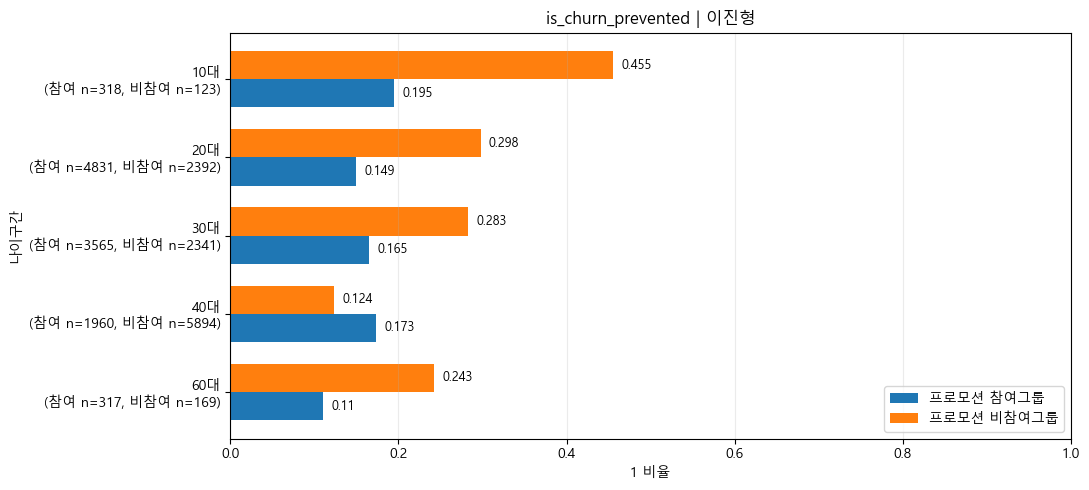

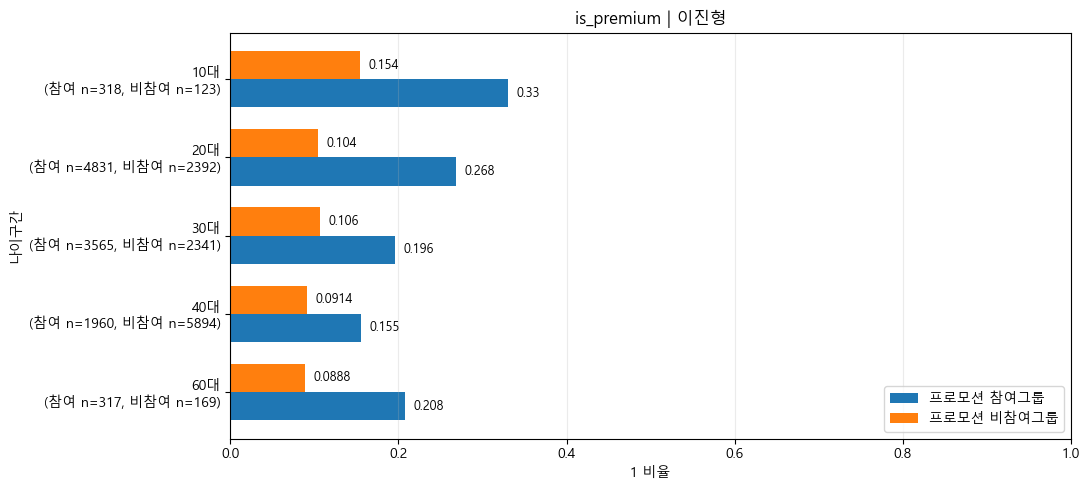

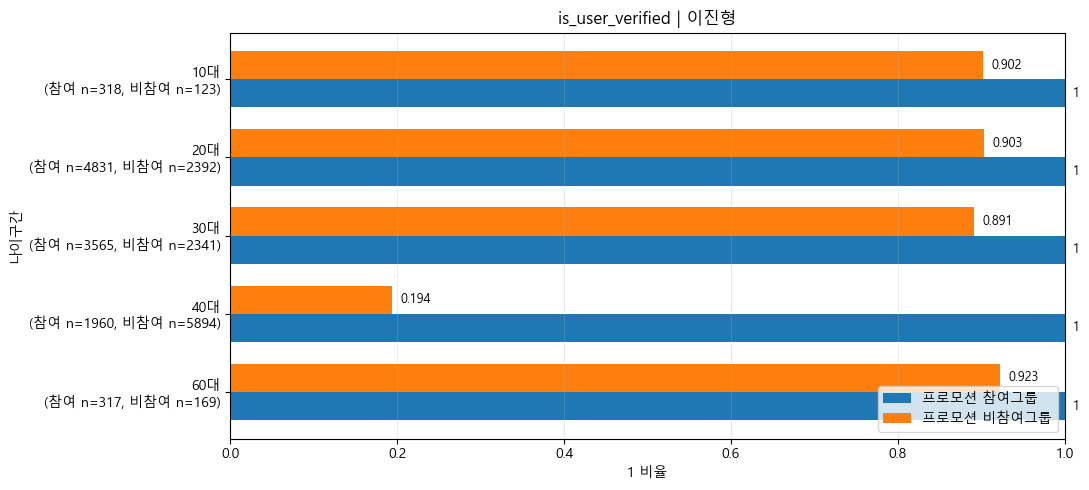

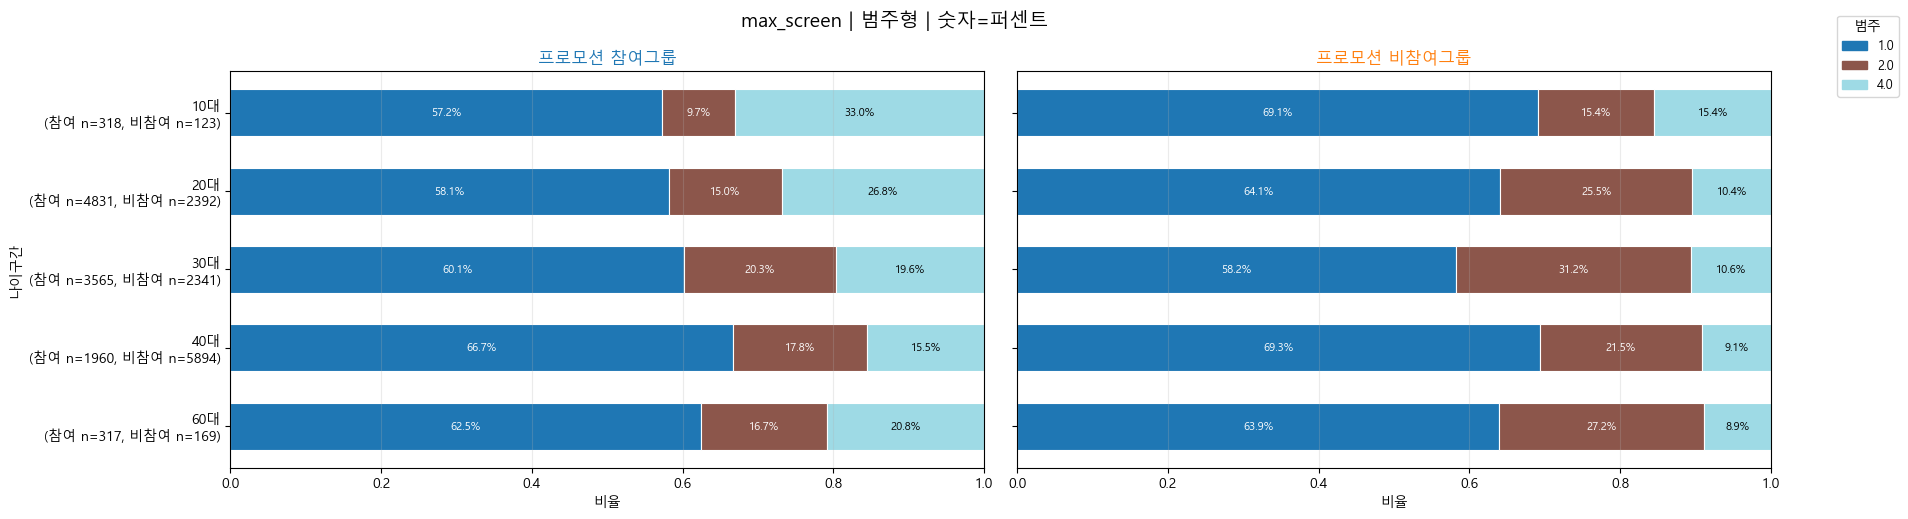

max_screen,1.0,2.0,4.0
10대 | 참여,57.2,9.7,33.0
20대 | 참여,58.1,15.0,26.8
30대 | 참여,60.1,20.3,19.6
40대 | 참여,66.7,17.8,15.5
60대 | 참여,62.5,16.7,20.8
10대 | 비참여,69.1,15.4,15.4
20대 | 비참여,64.1,25.5,10.4
30대 | 비참여,58.2,31.2,10.6
40대 | 비참여,69.3,21.5,9.1
60대 | 비참여,63.9,27.2,8.9


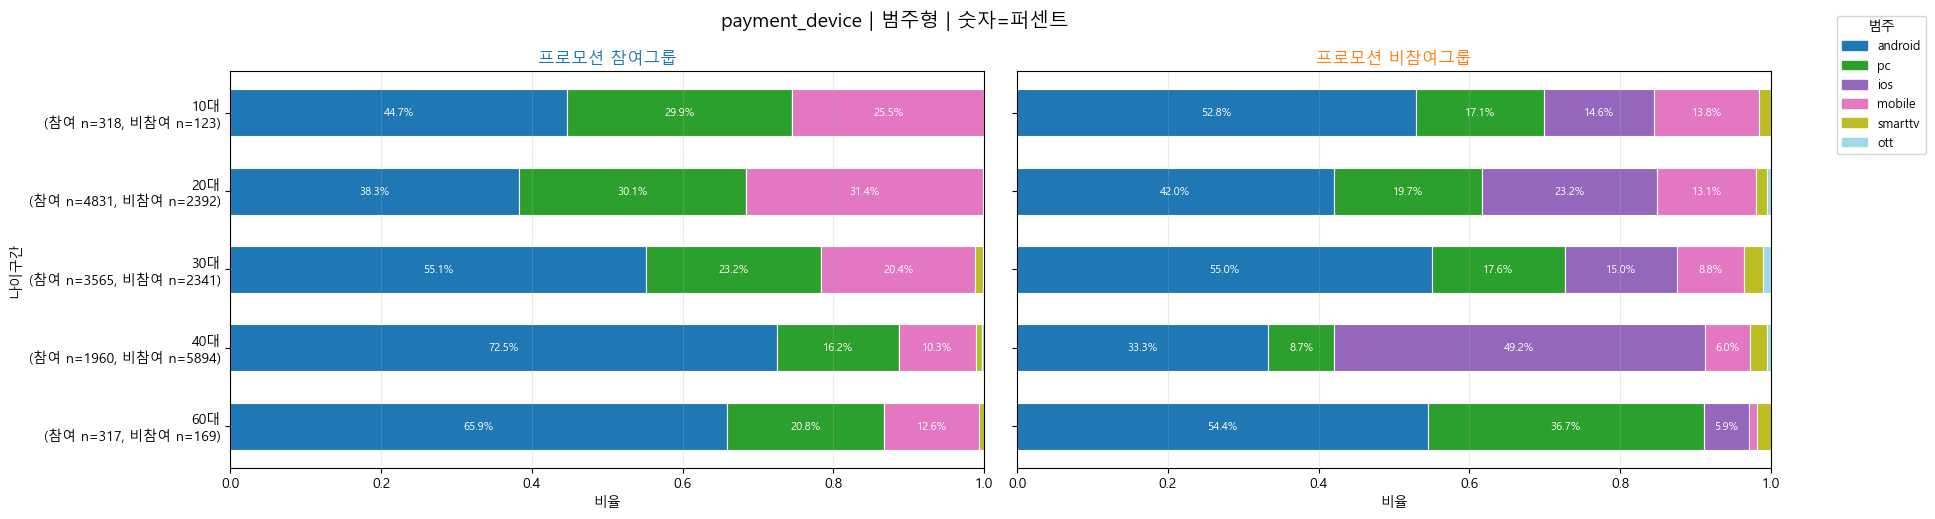

payment_device,android,pc,ios,mobile,smarttv,ott
10대 | 참여,44.7,29.9,0.0,25.5,0.0,0.0
20대 | 참여,38.3,30.1,0.0,31.4,0.1,0.0
30대 | 참여,55.1,23.2,0.0,20.4,1.1,0.1
40대 | 참여,72.5,16.2,0.0,10.3,0.8,0.3
60대 | 참여,65.9,20.8,0.0,12.6,0.6,0.0
10대 | 비참여,52.8,17.1,14.6,13.8,1.6,0.0
20대 | 비참여,42.0,19.7,23.2,13.1,1.4,0.5
30대 | 비참여,55.0,17.6,15.0,8.8,2.6,1.0
40대 | 비참여,33.3,8.7,49.2,6.0,2.2,0.6
60대 | 비참여,54.4,36.7,5.9,1.2,1.8,0.0


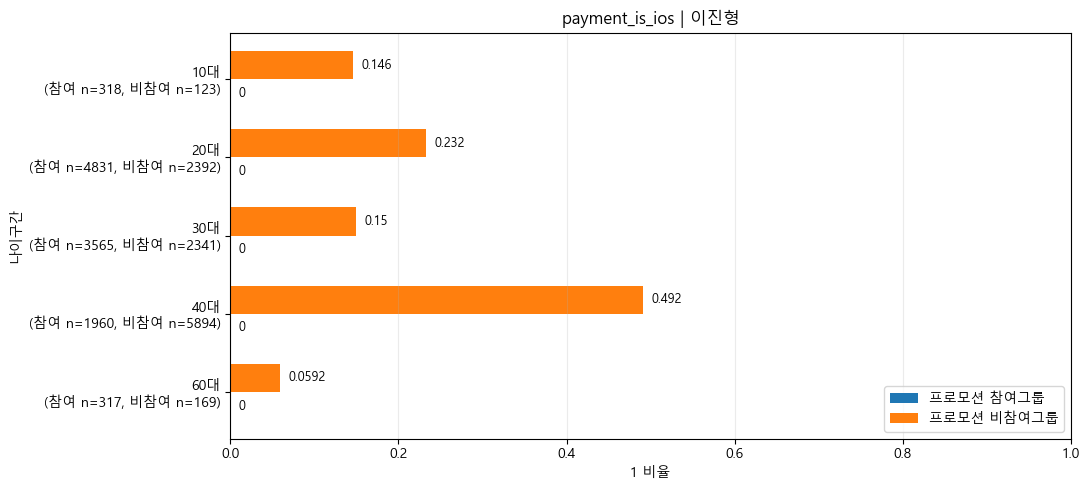

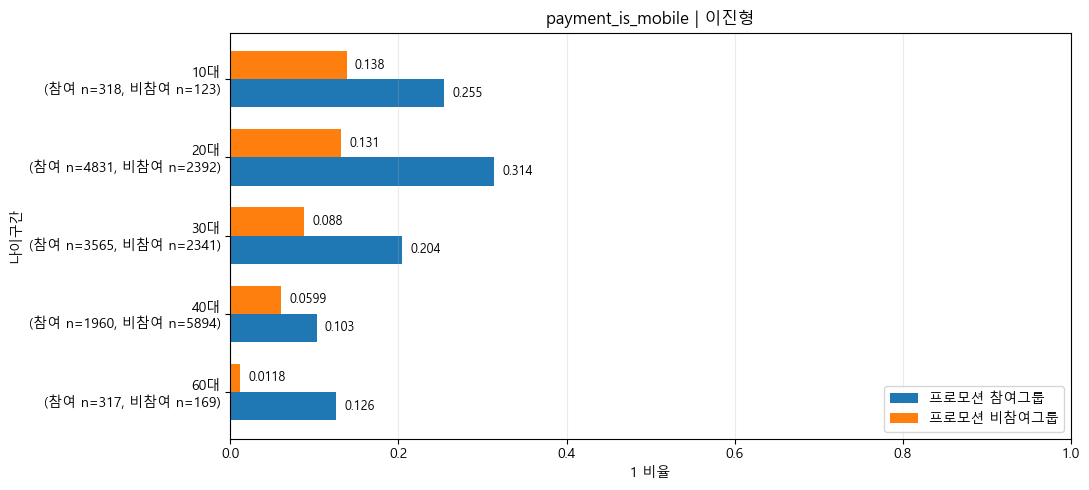

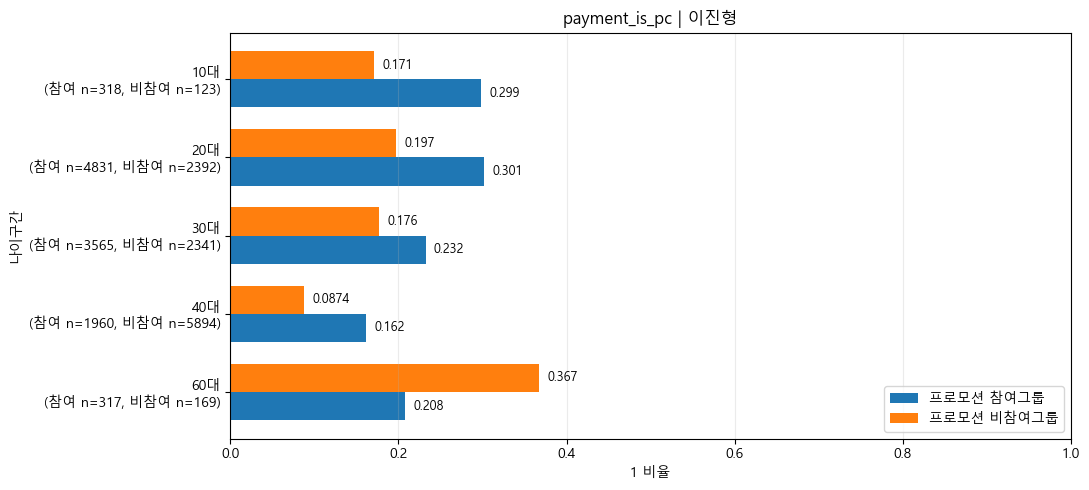

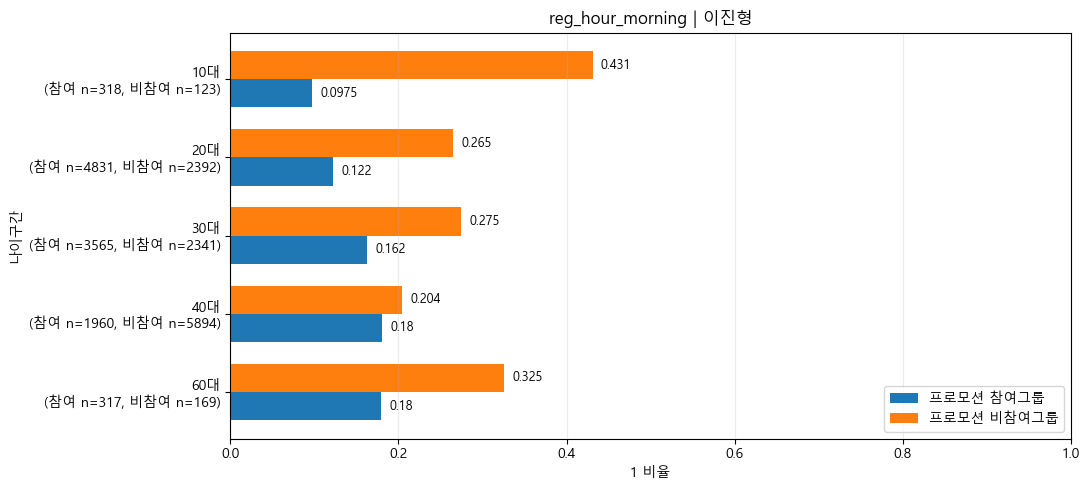

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from IPython.display import display

# 한글 표시 설정값 정의
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 색상 설정값 정의
promo_color = "#1f77b4"
nonpromo_color = "#ff7f0e"
bar_height = 0.36
min_ratio_for_label = 0.03

# 시각화 제외 컬럼 정의
excluded_plot_features = {"product_code"}

# 실행 전 변수 확인값 정의
required_variables = [
    "membership",
    "significant_age_groups",
    "common_features",
    "categorical_features",
]

missing_variables = [
    var_name for var_name in required_variables
    if var_name not in globals()
]

if missing_variables:
    raise ValueError(
        f"먼저 공통 유의 컬럼 계산 코드 실행 필요: {', '.join(missing_variables)}"
    )

# 이진형 정규화 함수 정의
def normalize_binary_series_for_plot(series):
    temp = series.copy()

    if pd.api.types.is_object_dtype(temp) or pd.api.types.is_string_dtype(temp):
        temp = temp.astype(str).str.strip()

    temp = temp.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
            "True": 1,
            "False": 0,
            "true": 1,
            "false": 0,
        }
    )

    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]

    return temp.astype(int)

# 이진형 여부 판별 함수 정의
def is_binary_like(series):
    temp = normalize_binary_series_for_plot(series)

    if len(temp) == 0:
        return False

    return set(temp.unique()).issubset({0, 1})

# 시각화 타입 판별 함수 정의
def infer_plot_type(df, feature_name, categorical_features):
    if feature_name in categorical_features:
        return "categorical"

    if is_binary_like(df[feature_name]):
        return "binary"

    return "numeric"

# 나이대별 표본 수 라벨 생성 함수 정의
def build_age_group_labels_with_n(df, age_group_order):
    labels = []

    for age_group in age_group_order:
        age_df = df[df["age_group"].astype(str) == age_group].copy()

        promo_n = int((age_df["is_promotion"] == 1).sum())
        nonpromo_n = int((age_df["is_promotion"] == 0).sum())

        labels.append(
            f"{age_group}\n(참여 n={promo_n}, 비참여 n={nonpromo_n})"
        )

    return labels

# 수치형 막대 라벨 함수 정의
def add_bar_labels(ax, bars):
    x_right = ax.get_xlim()[1]
    x_offset = x_right * 0.01 if x_right != 0 else 0.01

    for bar in bars:
        width = bar.get_width()

        if pd.isna(width):
            continue

        y_pos = bar.get_y() + bar.get_height() / 2

        ax.text(
            width + x_offset,
            y_pos,
            f"{width:.3g}",
            va="center",
            ha="left",
            fontsize=9
        )

# 색상 대비용 글자색 선택 함수 정의
def get_contrast_text_color(color):
    r, g, b = mcolors.to_rgb(color)
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b

    if luminance > 0.6:
        return "black"

    return "white"

# 범주형 퍼센트 라벨 함수 정의
def add_stacked_percent_labels(ax, ratio_table, color_map, y_positions, min_ratio):
    for row_idx, age_group in enumerate(ratio_table.index):
        left_value = 0.0

        for category_name in ratio_table.columns:
            width = ratio_table.loc[age_group, category_name]

            if width <= 0:
                continue

            if width >= min_ratio:
                x_center = left_value + width / 2
                text_color = get_contrast_text_color(color_map[category_name])

                ax.text(
                    x_center,
                    y_positions[row_idx],
                    f"{width * 100:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=text_color
                )

            left_value += width

# 수치형/이진형 요약 테이블 생성 함수 정의
def build_numeric_or_binary_summary(df, feature_name, age_group_order):
    plot_type = "binary" if is_binary_like(df[feature_name]) else "numeric"
    rows = []

    for age_group in age_group_order:
        age_df = df[df["age_group"].astype(str) == age_group].copy()

        promo_df = age_df[age_df["is_promotion"] == 1].copy()
        nonpromo_df = age_df[age_df["is_promotion"] == 0].copy()

        if plot_type == "binary":
            promo_values = normalize_binary_series_for_plot(promo_df[feature_name])
            nonpromo_values = normalize_binary_series_for_plot(nonpromo_df[feature_name])

            promo_value = promo_values.mean() if len(promo_values) > 0 else np.nan
            nonpromo_value = nonpromo_values.mean() if len(nonpromo_values) > 0 else np.nan

        else:
            promo_values = pd.to_numeric(promo_df[feature_name], errors="coerce").dropna()
            nonpromo_values = pd.to_numeric(nonpromo_df[feature_name], errors="coerce").dropna()

            promo_value = promo_values.median() if len(promo_values) > 0 else np.nan
            nonpromo_value = nonpromo_values.median() if len(nonpromo_values) > 0 else np.nan

        rows.append(
            {
                "age_group": age_group,
                "promo_value": promo_value,
                "nonpromo_value": nonpromo_value,
            }
        )

    summary_df = pd.DataFrame(rows)

    return summary_df, plot_type

# 수치형/이진형 그래프 함수 정의
def plot_numeric_or_binary_feature(df, feature_name, age_group_order):
    summary_df, plot_type = build_numeric_or_binary_summary(
        df=df,
        feature_name=feature_name,
        age_group_order=age_group_order
    )

    age_group_labels = build_age_group_labels_with_n(df, age_group_order)
    y = np.arange(len(summary_df))

    fig, ax = plt.subplots(figsize=(11, max(4.8, len(summary_df) * 1.0)))

    promo_bars = ax.barh(
        y + bar_height / 2,
        summary_df["promo_value"],
        height=bar_height,
        color=promo_color,
        label="프로모션 참여그룹"
    )

    nonpromo_bars = ax.barh(
        y - bar_height / 2,
        summary_df["nonpromo_value"],
        height=bar_height,
        color=nonpromo_color,
        label="프로모션 비참여그룹"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(age_group_labels)
    ax.invert_yaxis()
    ax.set_ylabel("나이구간")

    if plot_type == "binary":
        ax.set_xlabel("1 비율")
        ax.set_xlim(0, 1)
        ax.set_title(f"{feature_name} | 이진형")
    else:
        ax.set_xlabel("중앙값")
        ax.set_title(f"{feature_name} | 수치형")

    ax.grid(axis="x", alpha=0.25)
    ax.legend(loc="lower right")

    add_bar_labels(ax, promo_bars)
    add_bar_labels(ax, nonpromo_bars)

    plt.tight_layout()
    plt.show()

# 범주형 비율 테이블 생성 함수 정의
def build_categorical_ratio_table(df, feature_name, age_group_order, promo_value):
    temp = df[
        df["age_group"].astype(str).isin(age_group_order) &
        (df["is_promotion"] == promo_value)
    ].copy()

    temp = temp[temp[feature_name].notna()].copy()
    temp[feature_name] = temp[feature_name].astype(str)

    if len(temp) == 0:
        return pd.DataFrame()

    category_order = (
        df[feature_name]
        .dropna()
        .astype(str)
        .value_counts()
        .index
        .tolist()
    )

    ratio_table = pd.crosstab(
        temp["age_group"].astype(str),
        temp[feature_name],
        normalize="index"
    )

    ratio_table = ratio_table.reindex(
        index=age_group_order,
        columns=category_order,
        fill_value=0
    )

    return ratio_table

# 범주형 퍼센트 표 생성 함수 정의
def build_categorical_display_table(promo_table, nonpromo_table):
    promo_pct = (promo_table * 100).round(1)
    nonpromo_pct = (nonpromo_table * 100).round(1)

    promo_pct.index = [f"{idx} | 참여" for idx in promo_pct.index]
    nonpromo_pct.index = [f"{idx} | 비참여" for idx in nonpromo_pct.index]

    display_table = pd.concat([promo_pct, nonpromo_pct], axis=0)

    return display_table

# 범주형 그래프 함수 정의
def plot_categorical_feature(df, feature_name, age_group_order):
    promo_table = build_categorical_ratio_table(
        df=df,
        feature_name=feature_name,
        age_group_order=age_group_order,
        promo_value=1
    )

    nonpromo_table = build_categorical_ratio_table(
        df=df,
        feature_name=feature_name,
        age_group_order=age_group_order,
        promo_value=0
    )

    if promo_table.empty and nonpromo_table.empty:
        return

    if promo_table.empty:
        promo_table = pd.DataFrame(
            0,
            index=age_group_order,
            columns=nonpromo_table.columns
        )

    if nonpromo_table.empty:
        nonpromo_table = pd.DataFrame(
            0,
            index=age_group_order,
            columns=promo_table.columns
        )

    all_categories = list(
        dict.fromkeys(list(promo_table.columns) + list(nonpromo_table.columns))
    )

    promo_table = promo_table.reindex(index=age_group_order, columns=all_categories, fill_value=0)
    nonpromo_table = nonpromo_table.reindex(index=age_group_order, columns=all_categories, fill_value=0)

    age_group_labels = build_age_group_labels_with_n(df, age_group_order)
    y = np.arange(len(age_group_order))

    cmap = plt.get_cmap("tab20", len(all_categories))
    category_colors = {
        category_name: cmap(idx)
        for idx, category_name in enumerate(all_categories)
    }

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, max(5.2, len(age_group_order) * 1.05)),
        sharey=True
    )

    left_values = np.zeros(len(age_group_order))
    for category_name in all_categories:
        axes[0].barh(
            y,
            promo_table[category_name].values,
            left=left_values,
            height=0.6,
            color=category_colors[category_name],
            edgecolor="white",
            linewidth=0.8
        )
        left_values += promo_table[category_name].values

    left_values = np.zeros(len(age_group_order))
    for category_name in all_categories:
        axes[1].barh(
            y,
            nonpromo_table[category_name].values,
            left=left_values,
            height=0.6,
            color=category_colors[category_name],
            edgecolor="white",
            linewidth=0.8
        )
        left_values += nonpromo_table[category_name].values

    axes[0].set_yticks(y)
    axes[0].set_yticklabels(age_group_labels)
    axes[0].invert_yaxis()

    for ax in axes:
        ax.set_xlim(0, 1)
        ax.set_xlabel("비율")
        ax.grid(axis="x", alpha=0.25)

    axes[0].set_ylabel("나이구간")
    axes[0].set_title("프로모션 참여그룹", color=promo_color)
    axes[1].set_title("프로모션 비참여그룹", color=nonpromo_color)

    add_stacked_percent_labels(
        ax=axes[0],
        ratio_table=promo_table,
        color_map=category_colors,
        y_positions=y,
        min_ratio=min_ratio_for_label
    )

    add_stacked_percent_labels(
        ax=axes[1],
        ratio_table=nonpromo_table,
        color_map=category_colors,
        y_positions=y,
        min_ratio=min_ratio_for_label
    )

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=category_colors[category_name])
        for category_name in all_categories
    ]

    fig.legend(
        legend_handles,
        all_categories,
        title="범주",
        bbox_to_anchor=(1.02, 0.98),
        loc="upper left",
        fontsize=9
    )

    fig.suptitle(
        f"{feature_name} | 범주형 | 숫자=퍼센트",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    display_table = build_categorical_display_table(
        promo_table=promo_table,
        nonpromo_table=nonpromo_table
    )
    display(display_table)

# 시각화 대상 데이터 준비
plot_df = membership[
    membership["age_group"].astype(str).isin(significant_age_groups)
].copy()

# 시각화 대상 컬럼 준비
plot_features = [
    feature_name for feature_name in common_features
    if feature_name not in excluded_plot_features
]

# 공통 유의 컬럼별 그래프 출력
if not plot_features:
    print("없음")
else:
    for feature_name in plot_features:
        plot_type = infer_plot_type(
            df=plot_df,
            feature_name=feature_name,
            categorical_features=categorical_features
        )

        if plot_type == "categorical":
            plot_categorical_feature(
                df=plot_df,
                feature_name=feature_name,
                age_group_order=significant_age_groups
            )
        else:
            plot_numeric_or_binary_feature(
                df=plot_df,
                feature_name=feature_name,
                age_group_order=significant_age_groups
            )
